### Migrating from pyasro.py to pyastro.ipynb (notebook format)...... Created on Tue Feb 5, 2026 @author: rh<br>

- Convert .py script into a .ipynb notebook directly within Google Colab, using the colab-convert Library (Recommended)<br>

- Open a new notebook in Google Colab. Upload your .py file to the session storage (click the Folder icon on the left sidebar, then the Upload button).<br>

- Install and run the colab-convert utility in a code cell:<br>

  !pip install colab-convert<br>

  !colab-convert your_script.py your_notebook.ipynb<br>

- Refresh the file explorer on the left to see your new .ipynb file, then right-click to download it or open it.<br>

In [ ]:
from google.colab import drive
drive.mount('/content/drive') # Mount the Google Drive in the Colab /content directory
#drive.mount('/mnt/gdrive') # Mount the Google Drive in the /mnt directory

#import pandas as pd
#df = pd.read_csv("/mnt/gdrive/MyDrive/Colab Notebooks/iris.csv") # test the mounted drive
#print(df[:4])

# copy file from Google drive to Colab drive
#!cp /content/drive/MyDrive/Colab\ Notebooks/TestPy.py /content/TestPy.py

# import files from local drive to Colab drive
#from google.colab import files
#src = list(files.upload().values())[0] # upload files from local drive to Colab drive
#open('/content/test.py','wb').write(src)

# run the TestPy.py directly in Colab drive
#!python /content/TestPy.ipynb

# run the TestPy.py directly in Colab drive
#import TestPy.py

#  use the built-in nbformat library to upload .py script to Colab, and convert to .ipynb notebook format
#import nbformat
#from nbformat.v4 import new_notebook, new_code_cell
#with open('TestPy.py', 'r') as f:
#    code = f.read()
#nb = new_notebook()
#nb.cells.append(new_code_cell(code))
#with open('/content/drive/MyDrive/Colab\ Notebooks/TestPy.ipynb', 'w') as f:
#    nbformat.write(nb, f)


Mounted at /content/drive


In [ ]:
import os # Get and print the current working directory
cwd = os.getcwd()
print("Current working directory: {0}".format(cwd))

#os.chdir("/content") # Change the current working directory

Current working directory: /content


1. Numpy is a collection of mathematical and numerical functions, from
sin and cos to integration and linear algebra. We will use this instead
of the python math module, which also has basic mathematical functions.

In [ ]:
import numpy as np

2. Scipy is a collection of functions for scientific calculations.
We will use the scipy functionality for curve fitting, for instance.

In [ ]:
#!pip install scipy
from scipy import cluster
print(scipy.__version__)
#help(cluster)

1.16.3


3. Astropy has functions for astronomers, including those that let us deal
with files in the fits format and those that help us with calculating
astronomical quantities.

In [ ]:
#!pip install astropy
import astropy
#print(astropy.__version__)
from astropy import constants as const
from astropy import units as u

7.2.0


4. Matplotlib is go-to library for plotting diagrams of various kinds.

In [ ]:
import matplotlib.pyplot as plt

5. Random module in Python provides functions of picking a random sample from a larger subset,
i.e. a random floating point number x with 0  < x < 1.

In [ ]:
import random
# random.random()
# Returns a random integer i with p  < i  < q.
random.randint(2,44)

7

In [ ]:
# Create a random subset of k elements from a list thisList
thisList = range(100)
random.sample(thisList,5)

[58, 25, 65, 76, 33]

In [ ]:
# Draw random values from specific probability distributions, e.g. Gaussian (normal) distribution with mean mu and standard deviation stdDev.
mu = 5
stdDev = 2
random.gauss(mu,stdDev)

8.593294889907535

6. Format function builds strings out of numbers and other variables: You create a string that includes a placeholder built
from curly brackets. The string is followed by .format(), where the
parentheses enclose those variables that are to be substituted for the placeholders, e.g. insert an integer value into a file name:

In [ ]:
# Format function
thisInt = 10
print("egon{}.jpg".format(thisInt))
print("egon{:03d}.jpg".format(thisInt))
thisFloat=1.51515151515151515
print("This is a floating point number: {:f}(see?)".format(thisFloat))
# For scientific formatting with an exponential, use {:e},
thisFloat=151515.1515
print("This is a floating point number: {:e}(see?)".format(thisFloat))
# Placeholder only switches to exponentialjs for numbers smaller than 10^闁???4
thisFloat=0.0001515
print("This is a floating point number: {:g}(see?)".format(thisFloat))
thisFloat=0.00001515
print("This is a floating point number: {:g}(see?)".format(thisFloat))

egon10.jpg
egon010.jpg
This is a floating point number: 1.515152(see?)
This is a floating point number: 1.515152e+05(see?)
This is a floating point number: 0.0001515(see?)
This is a floating point number: 1.515e-05(see?)


In [ ]:
# Concatenate strings, just use the plus sign:
Strg = "def" + "def"
print(Strg)

7. Python 3.6 onwards has a simpler way of formatting numbers to yield strings, with f in front of the quotation marks, telling Python that this is an f-string, and the expressions in curly numbers are interpreted as formatting instructions.

In [ ]:
thisFloat=0.0001515
print(f"This is a floating point number:{thisFloat:g} (see?)")

# Strings can be addressed as lists of characters
thisString="ABCDEFGHIJKLMNOP"
print(thisString[3:6])

This is a floating point number:0.0001515 (see?)
DEF


8. Astronomical example - automatically create a URL to download a spectrum from SDSS (Sloan Digital Sky Survey) data release 8. <br>

  Each SDSS observation took up to a few hundreds of spectra simultaneously. To this end, an aluminium plate was placed in the telescope focal plane, with a pattern of holes made to measure for the observing field in question. In each hole, a light-conducting fiber that captures the light from a specific object, conducting it to a spectrograph. Since some plates were used more than once, we need also specify the date of the observation, using the Modified Julian Date (MJD) common in astronomy. Specifying plate number, fibre number and date picks out the spectrum of a specific object. As the SDSS software evolves, spectra are sometimes re-analysed, so we need to specify the number of the reduction run  when the raw data was sent through a specific software pipeline to yield a reduced spectrum, suitable for astrophysics. To retrieve a specific spectrum from the SDSS server, we need combine those numbers into a suitable custom URL for download.

In [ ]:
run2d = 26
plate = 1324
mjd = 53088
fiberID = 456
baseURL = "http://data.sdss3.org/sas/dr8/sdss/"
dirURL = f"spectro/redux/{run2d}/spectra/{plate}/"
fileURL = f"spec-{plate}-{mjd}-{fiberID:04d}"
url = baseURL + dirURL + fileURL + ".fits"
print(url)

# download the file to the Colab working directory, with curl (client URL) and a system call, saved as spectrum.fits.
from subprocess import call
saveFileName= "spectrum.fits"
call(["curl", "-o", saveFileName, url]) # system call to download the file

http://data.sdss3.org/sas/dr8/sdss/spectro/redux/26/spectra/1324/spec-1324-53088-0456.fits


9. Strings and base n numbers as lists - Variables of different types can be transformed into each other. e.g., object IDs for the SDSS survey have long numbers to begin with; every object of the SDSS has a unique object ID, and every object for which a spectrum has been taken has a spectral object ID, specObjID. e.g. the object with the spectral object id 1490816872793270272, which is an elliptical galaxy. To extract the information contained in that long number, we put the specObjId into a suitable variable, and transform that to a binary number, using the function bin:

In [ ]:
specObjId = 1490816872793270272
binVersion=bin(specObjId)
print(specObjId)
print(bin(specObjId))
len(binVersion)

1490816872793270272
0b1010010110000011100100000110000010000000000000110100000000000


63

The 0b in the beginning indicates that what follows is a binary number.The conversion leaves out any
leading zeros. To restore them, we can use the zfill function. If we use the int function, specifying
base 2 as an extra argument, we can convert this into an ordinary integer: i.e. the object plate number,

In [ ]:
binVersion=bin(specObjId)[2:].zfill(64)
print(binVersion)
print(len(binVersion))
print(binVersion[0:16])
int(binVersion[0:16],2)

0001010010110000011100100000110000010000000000000110100000000000
64
0001010010110000


5296

10. Plotting a function



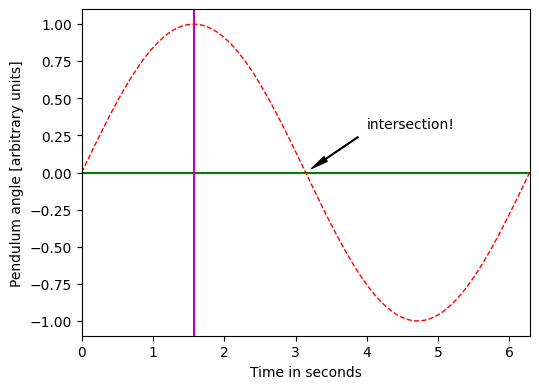

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(0,2*np.pi,200) # create 200 points, evenly distributed between (and including) the points 0 and 2*np.pi
y = np.sin(x)

plt.clf() # clears all figures that might have been plotted beforehand.
#plt.figure(figsize=(2,1))
plt.subplots_adjust(bottom=.2, left=.2) #stretches the display window
plt.xlabel("Time in seconds") # add x axis names.
plt.ylabel("Pendulum angle [arbitrary units]") # add y axis names.
# axvline and axhline add straight lines to show where x or y values are located w/ two different colors.
plt.axhline(0.0,color="g") # g specified the colour green
plt.axvline(0.5*np.pi,color= "m") # m specified the colour magenta
# Annotations - The xy tuple specifies where the arrow points, the xytext is where the annotation text should be displayed. The arrowprops option specifies the type of arrow to be used.
plt.annotate("intersection!", xy=(np.pi, 0), xytext=(4, 0.3),fontsize=10,
            arrowprops=dict(facecolor='black', headwidth=4, width=0.5, shrink=0.1))
plt.xlim(0,2*np.pi) # set the lowest and the highest value.
plt.ylim(-1.1,1.1) # set the lowest and the highest value.
plt.plot(x,y,"r",lw=1.0,linestyle="dashed") # r specified the colour red, LW set the line width, linestyle set the linestyle to shed
plt.show()

Scatter plots example: 5 galaxies with distance to Earth in Mpc and their redshift values. Then create a Hubble diagram, by plotting redshift values on the x axis and distance values on y axis. The plot function also plots a scatter diagram using a data marker shape,


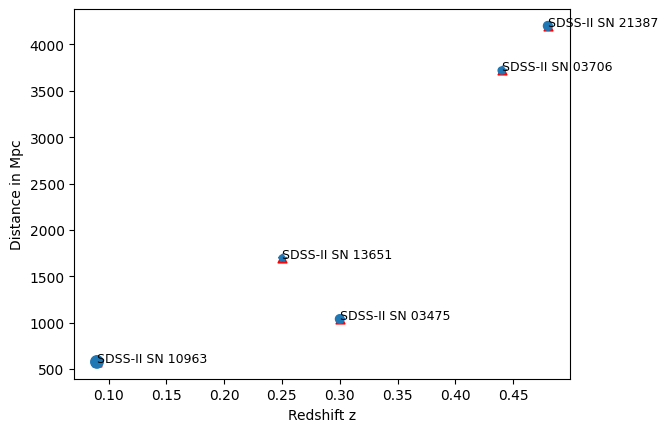

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Define lists containing the galaxy names, distances and redshifts.
nm = ["SDSS-II SN 21387","SDSS-II SN 13651","SDSS-II SN 03706","SDSS-II SN 10963","SDSS-II SN 03475"]
dpc=[4200.,1700.,3720.,577.,1040.]
zv=[0.48,0.25,0.44,0.09,0.3]
sizes = [40,15,25,80,38]

plt.clf()
# The options s changes the size of markers (size correspond to area, not diameter), color changes color, and marker changes the shape of the marker.
plt.scatter(zv,dpc,marker="^",s=40,color="r")
plt.scatter(zv,dpc,s=sizes)
plt.xlabel("Redshift z")
plt.ylabel("Distance in Mpc")
plt.plot(zv,dpc,"*")

# add name labels next to each scatter plot point
for i, txt in enumerate(nm):
    plt.text(zv[i], dpc[i], txt, fontsize=9)

plt.show()


Fitting data - polyfit function fits zv as x values and dpc as y values with a polynomial of degree 1, i.e. a linear function y = a  x + b. The Hubble-Lemaitre relation is: for distant galaxies, redshifts z and
distances d are related by z = Ho/c*d, with Ho as the Hubble constant and c the vacuum speed of light.<br>
Here y = d(dpc) e.g. 4200 and x = z(zv), e.g. 0.48 and using the estimated a = 9560 to calculate Ho = (3x10^5 km/s)/9560 = 31.4 km/s/Mpc, which is rather different from the best current values 70 km/s/Mpc. For the parameter a, we obtain 9560 with error 2321, so Hubble constant estimate comes with an error Ho = (31.4 +/- 7.6)km/s/Mpc

popt [9560.54352268 -735.48957908]
pcov [[ 5388477.11171705 -1681204.85885572]
 [-1681204.85885572   630020.74390196]]
perr [2321.30935287  793.73846064]


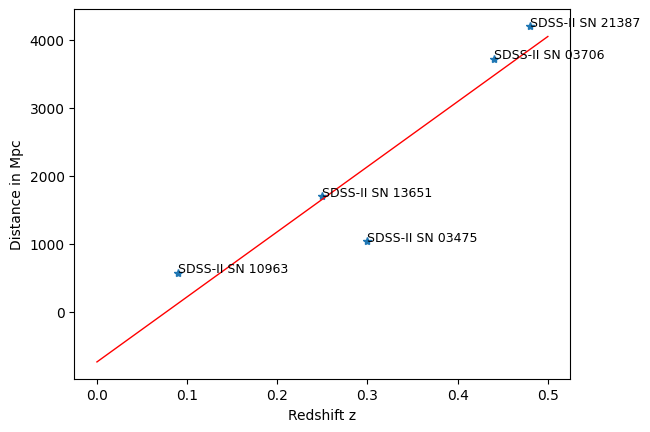

In [ ]:

# Scatter plots
plt.clf()
plt.xlabel("Redshift z")
plt.ylabel("Distance in Mpc")
plt.plot(zv,dpc,"*")

# Fitting data
popt,pcov = np.polyfit(zv,dpc,1,cov=True) # cov=True returns the associated covariance matrix.
perr = np.sqrt(np.diag(pcov)) # Square roots of the diagonal of matrix pcov gives estimates for the errors of the parameters.
print("popt", popt) # popt[0] = a and popt[1] = b
print("pcov", pcov) # pcov = covariance matrix
print("perr", perr) # estimates for the errors of the parameters

# add name labels next to each scatter plot point
for i, txt in enumerate(nm):
    plt.text(zv[i], dpc[i], txt, fontsize=9)

x = np.linspace(0,0.5,200)
y = x*popt[0] + popt[1]
plt.plot(x,y,"r",lw=1.0)

plt.show()

As Hubble-Lemaitre relation is actually y = ax, curve_fit of SciPy will fit data to a general function f(x). curve_fit has three inputs: the 1st is for our pre-defined fit function (fitFunc), the 2nd for x data and the 3rd for y data. The result is a = 7597.89 +/- 932.90, then Ho = (3x10^5 km/s)/a = (39.5 +/- 4.8) km/s/Mpc, so the discrepancy is due to something else.

popt [7597.89599991]
pcov [[870307.22665401]]
perr [932.90258155]


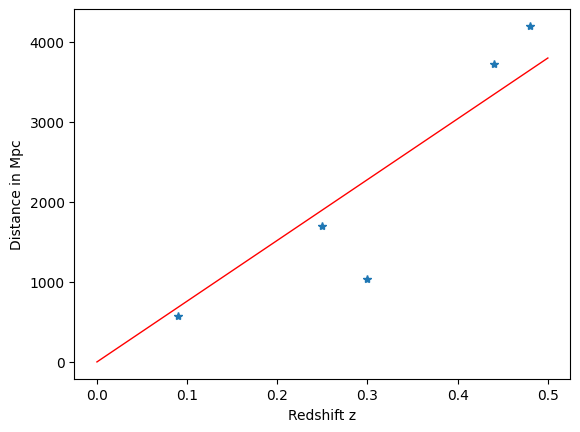

In [ ]:
from scipy.optimize import curve_fit

# Scatter plots
plt.clf()
plt.xlabel("Redshift z")
plt.ylabel("Distance in Mpc")
plt.plot(zv,dpc,"*")

# Fitting data
def fitFunc(x,a):
  return x*a
popt, pcov = curve_fit(fitFunc, zv, dpc)
perr = np.sqrt(np.diag(pcov))

print("popt", popt) # popt = a
print("pcov", pcov) # pcov = covariance
print("perr", perr) # estimates for the errors of the parameters

x = np.linspace(0,0.5,200)
y = x*popt
plt.plot(x,y,"r",lw=1.0)

plt.show()

Histograms - central limit theorem. The resulting histogram has no clear
structure; all values are of similar frequency, around the expectation value 10000/30 +/- 330, but with random fluctuations above and below that value.

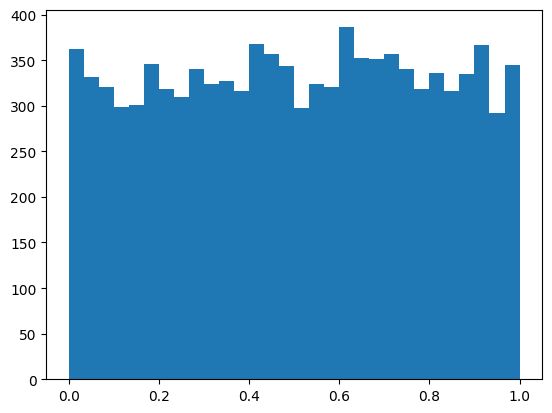

In [ ]:
import numpy as np
randArray = np.random.rand(10000)
plt.clf()
plt.hist(randArray,bins=30) # ns=30 means the histogram to have 30 bins.
plt.show()

If we add two random arrays, so that each number in the resulting array is the sum of two random numbers. Now, the histogram has a maximum in the middle, near 1, and smaller and larger values are less common.Because the sums of the integers between 1 and 5, there is only one way to obtain the 10, namely 5+5. But there are several ways to obtain 5: 4+1, 3+2, 2+3, 1+4. An outcome near the middle of the set is more likely.<br>

As we sums over more and more random numbers, the histogram looks more and more to a normal (Gaussian) distribution. The central limit theorem says for situation like this, where the sum of many random variables, all drawn from the
same probability distribution : as the number of terms in the sum grows, the resulting distribution comes ever closer to a normal distribution. <br>

Saving figures - file type is determined by the file extension, e.g pdf, png or jpg. Resolution for pixel-based formats can be set using the option dpi=300 for 300 dots per inch. The bbox_inches=tight makes sure the figure fits itself nicely into the allotted space.

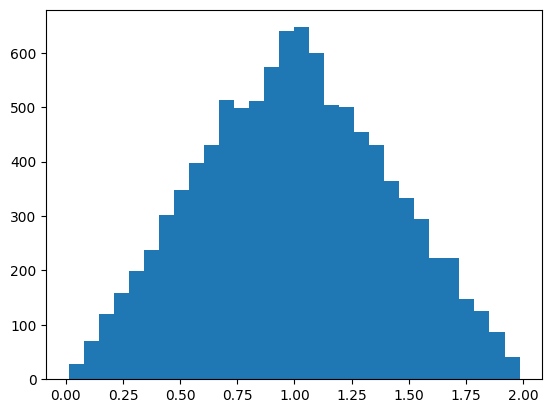

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Regenerate the histogram within this cell
randArray = np.random.rand(10000)+np.random.rand(10000)
plt.clf() # Clear any existing figure before plotting
plt.hist(randArray,bins=30) # ns=30 means the histogram to have 30 bins.

# Save the figure BEFORE showing it, or the pdf file will be blank!
plt.savefig("/content/histogram.pdf",dpi=300,bbox_inches="tight")

# Display the figure
plt.show()

? Glue is a multi-disciplinary tool at [https://glueviz.org]- interactive functionality glueing data sets for the different subsets,sorting them into different arrays, and plotting the results in the histograms and diagrams. That would be a matter of coding the distinctions we make, and the visualisations to select subsets from data, and then have that selection represented simultaneously in the relevant histograms and diagrams,

Open a FITS table - The hdulist variable contains all the HDUs (header/data units) of the FITS file. They consist of multiple data, e.g. image or a table or another type of array, and the header contains meta-information about the data. function, dex, and you will get a brief table of contents: (source: https://data.galaxyzoo.org).<br>
- The primary HDU is not commonly used for scientific data. <br>
- The second HDU, index 1, is a table stored in a binary format (BinTableHDU), with 243500 rows and 233 columns. K are 64-bit-integers, 11A is a string with 11 characters, I a 16 bit integer, E a single precision floating point. <br>

Once we have opened the HDULIST and assigned it to a variable hdulist, we can get the data via hdulist[1].data. tdata.field(specobjid) access a specific column from this table with column name


In [ ]:

from astropy.io import fits
hdulist = fits.open("/content/drive/MyDrive/Colab Notebooks/zoo2MainSpecz.fits")
hdulist.info()
hdulist[1].columns # hdulist[1] calls the 2nd columns attribute of the table.
tdata = hdulist[1].data
tdata
tdata.field("specobjid")
# index conventions to get specific elements
tdata.field("specobjid")[2]

Filename: /content/drive/MyDrive/Colab Notebooks/zoo2MainSpecz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (19741,)   uint8   
  1  Joined        1 BinTableHDU    480   243500R x 233C   [K, K, K, E, E, 11A, 11A, 20A, 20A, I, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I, I, E, E, E, E, I]   


np.int64(1489568922213574656)

Open an ASCII table. The csv file has been reduced to 9 entries. List index data["specobjid"][4] gives the 5th entry in that column,


In [ ]:

from astropy.io import ascii
data=ascii.read("/content/drive/MyDrive/Colab Notebooks/zoo2MainSpecz2.csv")
data.info
data
data["specobjid"]
data["specobjid"][4]

np.float64(1.38716535589755e+18)

## Access astronomical data in GAIA Virtual Observatory (VO) with pyvo.<br>
source: https://ar5iv.labs.arxiv.org/html/1905.13189#S4<br>
 The Milky Way, the Large Magellanic Cloud and the Small Magellanic Cloud are clearly visible.<br>


In [ ]:
!pip install astroquery
!pip install pyvo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.4 MB/s eta 0:00:00


In [ ]:

# Import the os module
import os
# Get and print the current working directory
cwd = os.getcwd()
print("Current working directory: {0}".format(cwd))
# Change the current working directory to C:\Users\Raymond\Documents\python
# os.chdir("python")

Current working directory: /content


In [ ]:

import requests
import numpy as np
import pyvo as vo
import matplotlib.pyplot as plt
serviceURL="https://gea.esac.esa.int/tap-server/tap"
service = vo.dal.TAPService(serviceURL)
# The multiline string inside double quotation marks " contains the ADQL. The properties galactic longitude l and galactic latitude b refer to the coordinate system in which the Milky Way band across the sky at latitude b=0. RANDOM_INDEX retrieves a random subsample of Gaia point sources.
resultset = service.search(
"""
SELECT TOP 1000000
l,b
FROM gaiadr2.gaia_source
ORDER BY RANDOM_INDEX
""")
# returned timeout/aborted error ?! so used astroquery below instead

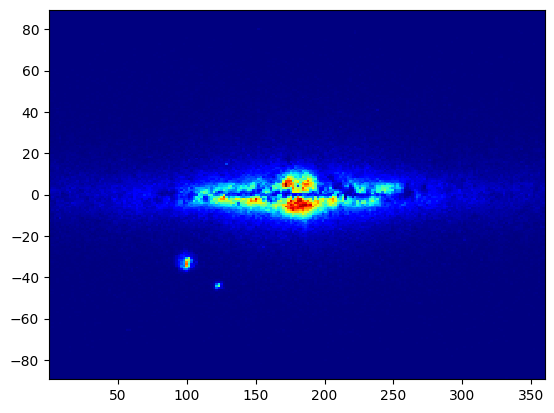

In [ ]:
plt.clf()
#  '+180.0) % 360' shifts the galactic longitude by 180 degrees, so the galactic center is at the centre of image, not around l=0. cmap=plt.cm.jet Sets the
# colormap to 'jet' (other colormaps incude 'viridis', 'plasma', 'inferno', 'magma', 'cividis').
plt.hist2d((resultset["l"]+180.0) % 360,resultset["b"], bins=(200, 200), cmap=plt.cm.jet)
# save the image to the Google drive in pdf
plt.savefig("/content/drive/MyDrive/Colab Notebooks/gaia-plot.pdf",bbox_inches="tight")
# Plot of Gaia stars, retrieved with PyVO
plt.show()

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
        l                   b         
       deg                 deg        
------------------ -------------------
27.465051949212157  -5.174943757191669
27.705489544679388  -5.505296851339382
 7.348721686304861  -5.291998750296857
 27.71424377720908  -5.437666514765527
1.8801951475020633 -6.5260069839331205


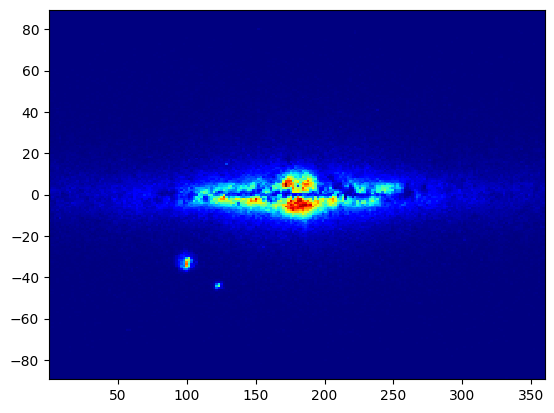

In [ ]:
# !pip install astroquery
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt

# Query to find stars within 100pc (parallax > 10 mas)
query = """
SELECT TOP 1000000
l,b
FROM gaiadr2.gaia_source
ORDER BY RANDOM_INDEX
"""

# Launch the job and get results
job = Gaia.launch_job_async(query)
results = job.get_results()

# Print the first few rows
print(results[:5])

plt.clf()
#  '+180.0) % 360' shifts the galactic longitude by 180 degrees, so the galactic center is at the centre of image, not around l=0. cmap=plt.cm.jet Sets the
# colormap to 'jet' (other colormaps incude 'viridis', 'plasma', 'inferno', 'magma', 'cividis').
plt.hist2d((results["l"]+180.0) % 360,results["b"], bins=(200, 200), cmap=plt.cm.jet)
# save the image to the Google drive in pdf
plt.savefig("/content/drive/MyDrive/Colab Notebooks/gaia-plot.pdf",bbox_inches="tight")
# Plot of Gaia stars, retrieved with PyVO
plt.show()

Select ra and dec of Andromeda galaxy (M31), from the table gaiadr2.gaia_source in Gaia DR2 (https://gea.esac.esa.int/tap-server/tap)<br>
  

In [ ]:
import pyvo as vo
import matplotlib.pyplot as plt
serviceURL="https://gea.esac.esa.int/tap-server/tap"
service = vo.dal.TAPService(serviceURL)
# CIRCLE specifies a circular region of radius 3.2 degrees in the sky, with center point at right ascension 10.684708 degrees
# and declination 41.268750 degrees, i.e. the center of the Andromeda galaxy. POINT selects the ra and dec in ICRS (International Celestial Reference System).
# CONTAINS returns 1 if the point is contained in the region, and 0 otherwise.
resultset = service.search(
"""
SELECT ra, dec
FROM gaiadr2.gaia_source
WHERE 1=CONTAINS(POINT('ICRS',ra,dec),
                    CIRCLE('ICRS',10.684708,41.268750, 3.2))
""")


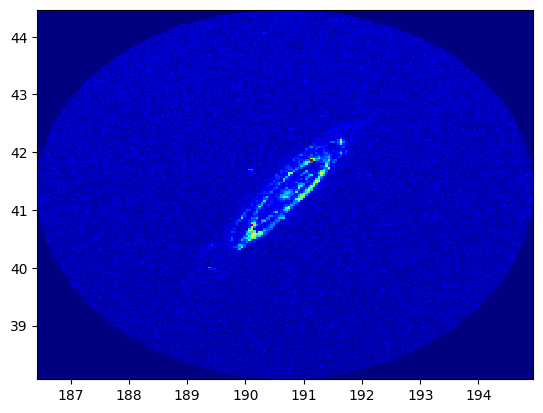

In [ ]:
plt.clf()
plt.hist2d((resultset["ra"]+180.0) % 360,resultset["dec"], bins=(200, 200), cmap=plt.cm.jet)
# Plot of Gaia stars, retrieved with PyVO
plt.show()

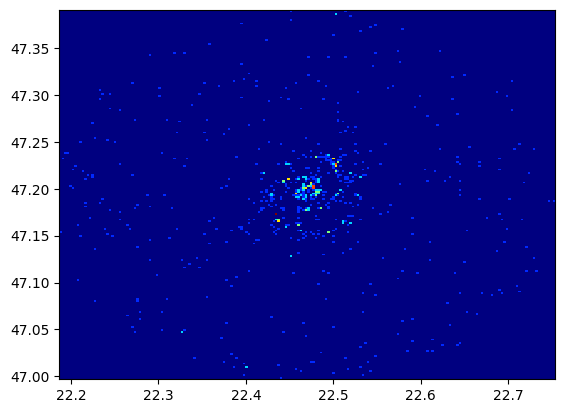

In [ ]:
# Whirlpool Galaxy(M51) using ra 202.4696 and dec 47.1952
serviceURL="https://gea.esac.esa.int/tap-server/tap"
service = vo.dal.TAPService(serviceURL)
resultset = service.search(
"""
SELECT ra, dec
FROM gaiadr2.gaia_source
WHERE 1=CONTAINS(POINT('ICRS',ra,dec),
                    CIRCLE('ICRS', 202.4696, 47.1952, 0.2))
""")

plt.clf()
plt.hist2d((resultset["ra"]+180.0) % 360, resultset["dec"], bins=(200, 200), cmap=plt.cm.jet)
# Plot of Gaia stars, retrieved with PyVO
plt.show()

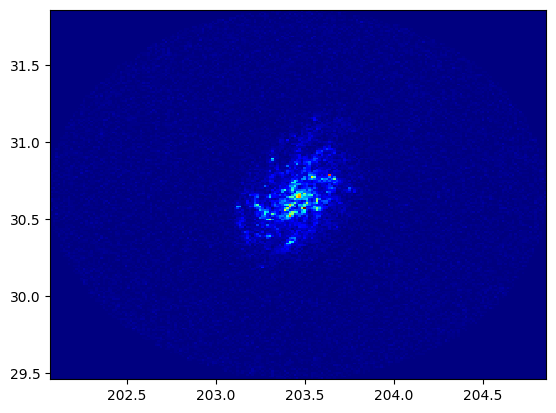

In [ ]:
# Triangulum Galaxy(M33) using ra 23.4621 and dec 30.6602
serviceURL="https://gea.esac.esa.int/tap-server/tap"
service = vo.dal.TAPService(serviceURL)
resultset = service.search(
"""
SELECT ra, dec
FROM gaiadr2.gaia_source
WHERE 1=CONTAINS(POINT('ICRS',ra,dec),
                    CIRCLE('ICRS', 23.4621, 30.6602, 1.2))
""")

plt.clf()
plt.hist2d((resultset["ra"]+180.0) % 360,resultset["dec"], bins=(200, 200), cmap=plt.cm.jet)
# Plot of Gaia stars, retrieved with PyVO
plt.show()

Find the brightest stars of the whole sky in the Gaia DR2 catalog. phot_g_mean_mag sets the magnitude
(i.e. the brightness expressed in the usual logarithmic scale of astronomy) of the object in the G filter band.
SELECT the TOP million of rows in ascending order(ASC), while descending order would be DESC.

In [ ]:
import pyvo as vo
import matplotlib.pyplot as plt
serviceURL="https://gea.esac.esa.int/tap-server/tap"
service = vo.dal.TAPService(serviceURL)
resultset = service.search(
"""
SELECT TOP 1000000 ra, dec, phot_g_mean_mag
FROM gaiadr2.gaia_source
ORDER BY phot_g_mean_mag ASC
""")
plt.clf()
plt.hist2d(resultset["ra"] % 360,resultset["dec"], bins=(200, 200), cmap=plt.cm.jet)
# Plot of Gaia stars, retrieved with PyVO
plt.show()

Select the top N rows for random_index, then get a random sub-sample from the table. column random_index
contains a random permutation of the integers from 1 to N. Note that this is not a generic ADQL feature,
but instead relies on the Gaia team having supplied an extra column random_index for the purpose.
The result shown as a plane plot with some extra structure, namely the Large Magellanic Cloud and the
Small Magellanic cloud, our nearest neighbouring galaxies, in the bottom left corner

In [ ]:
import pyvo as vo
import matplotlib.pyplot as plt
serviceURL="https://gea.esac.esa.int/tap-server/tap"
service = vo.dal.TAPService(serviceURL)
resultset = service.search(
"""
SELECT TOP 1000000 ra, dec
FROM gaiadr2.gaia_source
ORDER BY random_index
""")
plt.clf()
plt.hist2d(resultset["ra"] % 360,resultset["dec"], bins=(200, 200), cmap=plt.cm.jet)
# Plot of Gaia stars, retrieved with PyVO
plt.show()
# returned timeout/aborted error?!

In [ ]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.1 MB/s eta 0:00:00


In [ ]:
# !pip install astroquery
from astroquery.gaia import Gaia

# Query to find stars within 100pc (parallax > 10 mas)
query = """
SELECT TOP 1000000 ra, dec
FROM gaiadr2.gaia_source
ORDER BY random_index
"""

# Launch the job and get results
job = Gaia.launch_job_async(query)
results = job.get_results()

# Print the first few rows
print(results[:5])

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
        ra                 dec        
       deg                 deg        
------------------ -------------------
284.99739676167115  -7.213793616274905
285.40330935895224  -7.148584219945948
275.62676855936525 -25.133812456872477
 285.3463802481969  -7.110389961786362
274.00940943846905  -30.52512472355252


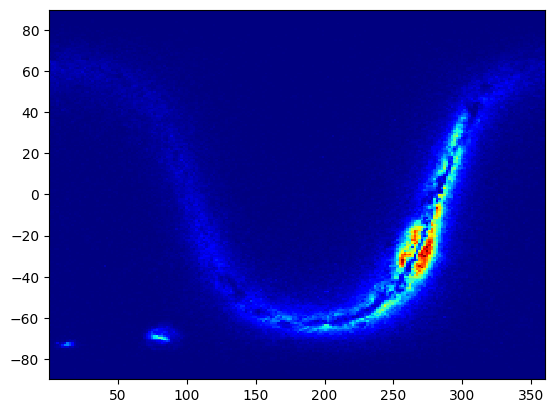

In [ ]:

plt.clf()
plt.hist2d(results["ra"] % 360,results["dec"], bins=(200, 200), cmap=plt.cm.jet)
# Plot of Gaia stars, retrieved with PyVO
plt.show()

1. Basic Data Query (Nearby Stars)
This script uses Asynchronous Querying to retrieve stars within a specific distance (e.g., 100 parsecs) from the Gaia DR3 archive.

In [ ]:
# !pip install astroquery
from astroquery.gaia import Gaia

# Query to find stars within 100pc (parallax > 10 mas)
query = """
SELECT TOP 1000
    source_id, ra, dec, parallax, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax > 10
ORDER BY parallax DESC
"""

# Launch the job and get results
job = Gaia.launch_job_async(query)
results = job.get_results()

# Print the first few rows
print(results[:5])


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
     source_id              ra         ...      parallax      phot_g_mean_mag
                           deg         ...        mas               mag      
------------------- ------------------ ... ------------------ ---------------
5853498713190525696 217.39232147200883 ...  768.0665391873573        8.984749
4472832130942575872 269.44850252543836 ...   546.975939730948       8.1939745
3864972938605115520 164.10319030755974 ... 415.17941567802137       11.038391
 762815470562110464 165.83095967577933 ... 392.75294543876464        6.551172
2947050466531873024 101.28662552099249 ... 374.48958852876103        8.524133


2. Plotting the Milky Way
To visualize Gaia data as a sky map or "face-on" view, use the specialized milkyway_plot library

In [ ]:
!pip install mw_plot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 32.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 41.5 MB/s eta 0:00:00
  Created wheel for mw_plot: filename=mw_plot-0.13.1-py3-none-any.whl size=38423439 sha256=954bf4a346d743d96f56e5a44647eb344dfc7a594236a44dc819d4786f6b915f
  Stored in directory: /root/.cache/pip/wheels/64/0d/14/06d54112470c26be163792996f1ddee2229b5fdce05e2584d6
Successfully built mw_plot


<Figure size 640x480 with 0 Axes>

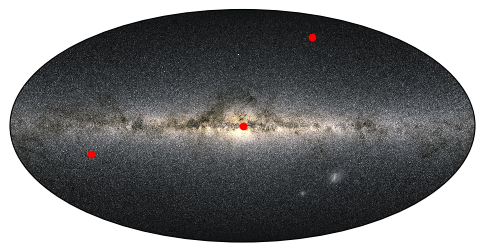

In [ ]:
from mw_plot import MWSkyMap
import matplotlib.pyplot as plt
import astropy.units as u
plt.clf()
# Initialize an all-sky map with Gaia background
mw = MWSkyMap(projection='mollweide', center=(0*u.degree, 0*u.degree)) # Pass Quantity objects
mw.initialize_mwplot()

# Add your Gaia data points (example using dummy RA/Dec)
ra = [266.41, 10.0, 180.0]
dec = [-29.0, 45.0, 0.0]
mw.mw_scatter(ra * u.degree, dec * u.degree, c='red')

plt.show()

3. Coordinate Transformation -
Converting Gaia's equatorial coordinates (RA,Dec, parallax) into Galactic
X,Y,Z positions is essential for mapping the disk

In [ ]:
import numpy as np
import pandas as pd

def get_galactic_coords(df):
    # Convert parallax (mas) to distance (parsecs)
    df['distance'] = 1000.0 / df['parallax']

    # Simple conversion using l (longitude) and b (latitude)
    l_rad = np.radians(df['l'])
    b_rad = np.radians(df['b'])

    df['X'] = df['distance'] * np.cos(b_rad) * np.cos(l_rad)
    df['Y'] = df['distance'] * np.cos(b_rad) * np.sin(l_rad)
    df['Z'] = df['distance'] * np.sin(b_rad)
    return df


4. This script uses ADQL to query the Gaia Archive for stars within a specific distance.

In [ ]:
from astroquery.gaia import Gaia
import astropy.units as u

# Define a query to get nearby stars (distance < 500 pc)
# We use DR3 (Data Release 3)
query = """
SELECT TOP 100 source_id, ra, dec, parallax, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax > 2  -- parallax in mas (2 mas = 500 pc)
"""

# Launch the job
job = Gaia.launch_job_async(query)
results = job.get_results()

# Print the first few rows
print(results[:5])


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
  source_id            ra         ...      parallax      phot_g_mean_mag
                      deg         ...        mas               mag      
-------------- ------------------ ... ------------------ ---------------
 1717987078400  44.98309734471892 ... 2.7367159160633827       18.629124
 2989297243776  45.14638633341736 ... 2.3588572979203497       17.871004
 5192616270720 44.973695505951675 ...  8.053747022265128       16.282227
11755326322560 45.321594692861574 ...  2.764855262197966       17.106558
22127671579520  44.75859538899197 ...  2.545819588544048        18.80459


Select the top N rows for random_index, then get a random sub-sample from the table. column random_index contains a random permutation of the integers from 1 to N. Note that this is not a generic ADQL feature, but instead relies on the Gaia team having supplied an extra column random_index for the purpose.
The result shown as a plane plot with some extra structure, namely the Large Magellanic Cloud and the Small Magellanic cloud, our nearest neighbouring galaxies, in the bottom left corner

In [ ]:

from astroquery.gaia import Gaia
import astropy.units as u

query = """
SELECT TOP 1000000 ra, dec
FROM gaiadr3.gaia_source
ORDER BY random_index
"""

# Launch the job
job = Gaia.launch_job_async(query)
results = job.get_results()

# Print the first few rows
print(results[:5])


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
        ra                 dec        
       deg                 deg        
------------------ -------------------
 286.7169128963743 0.27619460064099405
152.62506770596002   -64.2676994251119
348.43498221430735   43.94070420401419
 252.7297169379439 -37.917214705062186
 260.6787873092191 -44.788771692779804


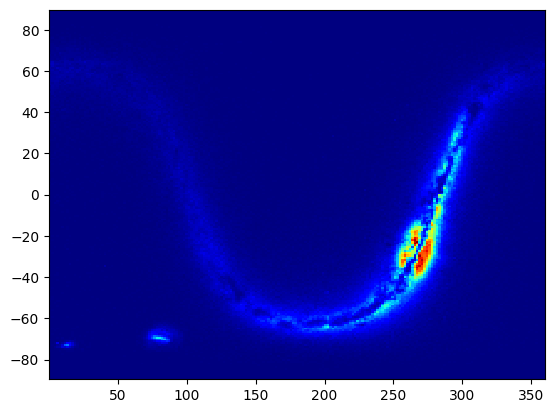

In [ ]:
plt.clf()
plt.hist2d(results["ra"] % 360,results["dec"], bins=(200, 200), cmap=plt.cm.jet)
# Plot of Gaia stars, retrieved with Astroquery
plt.show()

Find the brightest stars of the whole sky in the Gaia DR2 catalog. phot_g_mean_mag sets the magnitude (i.e. the brightness expressed in the usual logarithmic scale of astronomy) of the object in the G filter band.
SELECT the TOP million of rows in ascending order(ASC), while descending order would be DESC.

In [ ]:
from astroquery.gaia import Gaia
import pyvo as vo
import matplotlib.pyplot as plt
import astropy.units as u

query = """
SELECT TOP 1000000 ra, dec, phot_g_mean_mag
FROM gaiadr2.gaia_source
ORDER BY phot_g_mean_mag ASC
"""

# Launch the job
job = Gaia.launch_job_async(query)
results = job.get_results()

# Print the first few rows
print(results[:5])


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
        ra                dec         phot_g_mean_mag
       deg                deg               mag      
------------------ ------------------ ---------------
  326.046610958014  9.875017848222623       1.7076352
 89.88182329162628  44.94743204476693       1.7141398
14.177441204227053  60.71672247798855       1.8246739
 274.4061143187362 -36.76240607839242       1.9249064
221.24649351883244  27.07431392249596       1.9404473


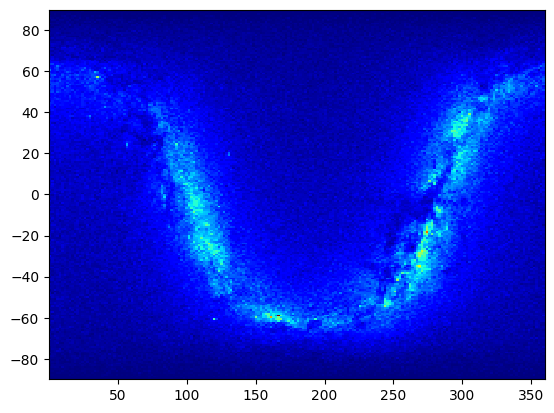

In [ ]:
import matplotlib.pyplot as plt
plt.clf()
plt.hist2d(results["ra"] % 360,results["dec"], bins=(200, 200), cmap=plt.cm.jet)
# Plot of Gaia stars, retrieved with Astroquery
plt.show()

Calculating Galactic Coordinates -
Once you have the data, you can convert Right Ascension (RA) and Declination (Dec) into Galactic Coordinates (L, B) and then to Cartesian (X, Y, Z) positions relative to the Galactic Center.


In [ ]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.5 MB/s eta 0:00:00


In [ ]:
print(results['ra'].data[5])
results.info()

44.85518643009974
<Table length=100>
      name       dtype  unit                            description                            
--------------- ------- ---- ------------------------------------------------------------------
      source_id   int64      Unique source identifier (unique within a particular Data Release)
             ra float64  deg                                                    Right ascension
            dec float64  deg                                                        Declination
       parallax float64  mas                                                           Parallax
phot_g_mean_mag float32  mag                                              G-band mean magnitude


In [ ]:
import numpy as np
from astropy.coordinates import SkyCoord

# Convert table columns to numpy arrays
ra = results['ra'].data
dec = results['dec'].data
parallax = results['parallax'].data
print(ra[:5])

In [ ]:

# Calculate distance in parsecs
distance_pc = 1000 / parallax
print(parallax[:5], distance_pc[:5])

[2.7367159160633827 2.3588572979203497 8.053747022265128 2.764855262197966
 2.545819588544048] [365.40146316627767 423.9340806591542 124.16580719948522 361.6825855849807
 392.8008113771719]


In [ ]:

# Create a SkyCoord object
c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, distance=distance_pc*u.pc, frame='icrs')
print(c[:5])

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(44.98309734, 0.09640646, 365.40146317),
     (45.14638633, 0.16035348, 423.93408066),
     (44.97369551, 0.15520353, 124.1658072 ),
     (45.32159469, 0.29601288, 361.68258558),
     (44.75859539, 0.25268895, 392.80081138)]>


In [ ]:

# Convert to Galactic coordinates
galactic = c.transform_to('galactic')
l_deg, b_deg = galactic.l.degree, galactic.b.degree
print(galactic[:5])

<SkyCoord (Galactic): (l, b, distance) in (deg, deg, pc)
    [(176.83795149, -48.847878  , 365.40146317),
     (176.94015315, -48.68596892, 423.93408066),
     (176.76381857, -48.81376063, 124.1658072 ),
     (176.9761726 , -48.46566685, 361.68258558),
     (176.42968074, -48.90001549, 392.80081138)]>


In [ ]:

# Simple Cartesian conversion (Sun-centric)
x = distance_pc * np.cos(np.radians(b_deg)) * np.cos(np.radians(l_deg))
y = distance_pc * np.cos(np.radians(b_deg)) * np.sin(np.radians(l_deg))
z = distance_pc * np.sin(np.radians(b_deg))
print(x[:5],y[:5],z[:5])

[-240.09017633025167 -279.47617422080924 -81.63388034052316
 -239.4865044002358 -257.716281262596] [13.263603010089891 14.939463314496242 4.615756028486489 12.65082600583673
 16.08010608350982] [-275.134536816002 -318.4179411137145 -93.44384438974228
 -270.7405834502149 -296.0003817211832]


<Figure size 640x480 with 0 Axes>

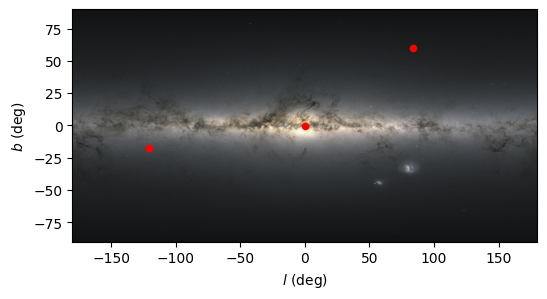

In [ ]:
from mw_plot import MWSkyMap
import matplotlib.pyplot as plt
import astropy.units as u
plt.clf()

# Initialize a Milky Way Sky Map
mw = MWSkyMap()

# Add your Gaia data points (example using dummy RA/Dec)
ra = [266.41, 10.0, 180.0]
dec = [-29.0, 45.0, 0.0]

# Plot your Gaia points (RA/Dec)
mw.mw_scatter(ra * u.degree, dec * u.degree, c='r')

# Display the map with the Gaia background
plt.show()


Select subsets (open cluster NGC 188) directly from a 2D plot ra and dec, but also the proper motion (i.e. the motion on the celestial sphere)
in the ra and dec directions, pmra and pmdec, respectively. bp_g is the blue minus the green brightness of the object,
which serves as a measure of colour, and phot_g_mean_mag is the magnitude (brightness) in Gaia broad G band, which
can stand in for the object overall brightness.  X as  and Y as dec will plot the proper motions of the stars

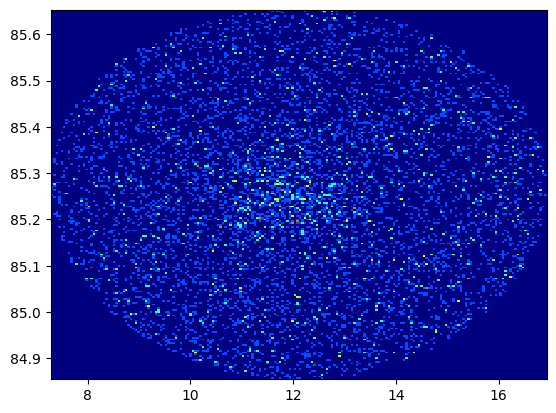

In [ ]:
import pyvo as vo
import matplotlib.pyplot as plt
serviceURL="https://gea.esac.esa.int/tap-server/tap"
service = vo.dal.TAPService(serviceURL)
resultset = service.search(
"""
SELECT ra, dec, pmra, pmdec, bp_g, phot_g_mean_mag
FROM gaiadr2.gaia_source
WHERE 1=CONTAINS(POINT('ICRS',ra,dec), CIRCLE('ICRS', 12.1083,85.2550, 0.4))
""")
plt.clf()
plt.hist2d(resultset["ra"],resultset["dec"] ,bins=(200, 200), cmap=plt.cm.jet)
# plt.hist2d(np.isfinite(resultset["bp_g"]),np.isfinite(resultset["phot_g_mean_mag"]),bins=(200, 200), cmap=plt.cm.jet)
# Plot of Gaia stars, retrieved with PyVO
plt.show()

Histograms for the subset (stars within the open cluster NGC 188)

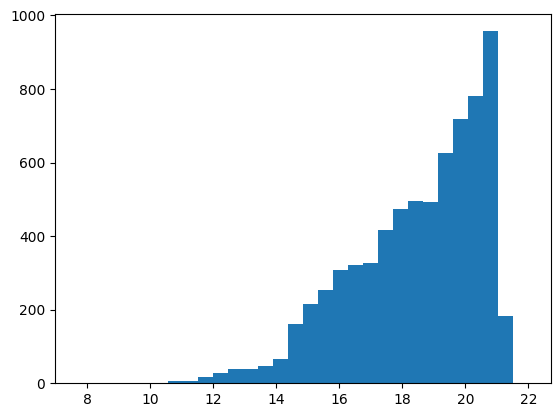

In [ ]:
import numpy as np
plt.clf()
plt.hist(resultset["phot_g_mean_mag"],bins=30)
plt.show()

Galaxy spectrum id 1237659161195249685 from SDSS DR8 data release 8 (telescopes located at Apache Point Observatory (APO) in New Mexico),
at http://skyserver.sdss.org/dr8/en/tools/explore/obj.asp. Download  FITS file spec-1330-52822-0304.fits (The file cannot be found).


Downloaded this file instead: /contentcontent/drive/MyDrive/Colab Notebooks/spec-1324-53088-0456.fits<br>
COADD is the spectrum we want. SPECOBJ contains general information about the object, while SPZLINE describes the spectral lines that have been identified in the spectrum. B1 and R1 are different exposures of the (overlapping) blue and red portions of the spectrum, recorded on separate chips; they have been added up and combined to give COADD.

In [ ]:

hdulist[1].columns

ColDefs(
    name = 'flux'; format = 'E'
    name = 'loglam'; format = 'E'
    name = 'ivar'; format = 'E'
    name = 'and_mask'; format = 'J'
    name = 'or_mask'; format = 'J'
    name = 'wdisp'; format = 'E'
    name = 'sky'; format = 'E'
    name = 'model'; format = 'E'
)

Filename: /content/drive/MyDrive/Colab Notebooks/spec-1324-53088-0456.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     139   ()      
  1  COADD         1 BinTableHDU     26   3847R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPECOBJ       1 BinTableHDU    262   1R x 126C   [6A, 4A, 16A, 23A, 16A, 8A, E, E, E, J, E, E, J, B, B, B, B, B, B, J, 22A, 19A, 19A, 22A, 19A, I, 3A, 3A, 1A, J, D, D, D, E, E, 19A, 8A, J, J, J, J, K, K, J, J, J, J, J, J, K, K, K, K, I, J, J, J, J, 5J, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, E, 5E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 25A, 21A, 10A, E, E, E, E, E, E, E, E, J, E, E, J, 1A, 1A, E, E, J, J, 1A, 5E, 5E]   
  3  SPZLINE       1 BinTableHDU     48   29R x 19C   [J, J, J, 13A, D, E, E, E, E, E, E, E, E, E, E, J, J, E, E]   
  4  B2-00025784-00025787-00025788    1 BinTableHDU    146   2045R x 7C   [E, E, E, J, E, E, E]   
  5  B2-00025785-00

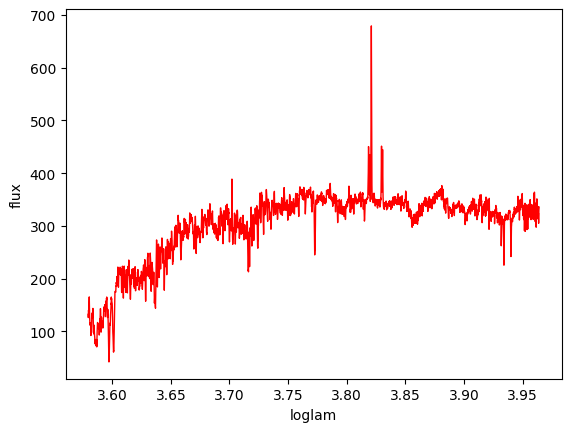

In [ ]:
from astropy.io import fits
hdulist = fits.open("/content/drive/MyDrive/Colab Notebooks/spec-1324-53088-0456.fits")
hdulist.info()
hdulist[1].columns
tdata = hdulist[1].data
tdata
tdata.field("flux")
# index conventions to get specific elements
tdata.field("flux")[2]

import matplotlib.pyplot as plt
import numpy as np

# Scatter plots
plt.clf()
plt.xlabel("loglam")
plt.ylabel("flux")
plt.plot(tdata.field("loglam"),tdata.field("flux"),"r",lw=1.0)
plt.show()

https://pyvo.readthedocs.io/en/latest/ : documentation for PyVO, an affiliated package for the astropy package.<br>
- Table Access Protocol (TAP)  accessing source catalogs using ADQL queries.
- Simple Image Access (SIA)  finding images in an archive.
- Simple Spectral Access (SSA)  finding spectra in an archive.
- Simple Cone Search (SCS)  for positional searching a source catalog or an observation log.
- Simple Line Access (SLAP)  finding data about spectral lines, including their rest frequencies.
require:numpy, astropy, requests


In [ ]:
!pip install astroquery
!pip install pyvo

In [ ]:
import pyvo as vo
# Table Access Protocol (TAP) access source catalogs vo.dal.TAPService, at GAVO (German Astrophysical Virtual Observatory).
service = vo.dal.TAPService("https://dc.g-vo.org/tap")
# Run database query: service.search.ivoa.obscore table contains generic metadata for datasets at GAVO.
resultset = service.search("SELECT TOP 3 * FROM ivoa.obscore")
resultset # The resultset object works like a numpy record array, which can be processed by columns or rows.
row = resultset[2]
row
column = resultset["dataproduct_type"]
column
columnlast = resultset["source_table"]
columnlast
for row in resultset:
  calib_level = row["calib_level"]
calib_level

np.int16(2)

Registry search - interrogate the IVOA Registry, e.g.  iterate over all TAP services supporting the obscore data model

In [ ]:
for service in vo.regsearch(datamodel="obscore"):
  print(service['ivoid'])

ivo://archive.stsci.edu/caomtap
ivo://astro.ucl.ac.uk/tap
ivo://astro.upjs/tap
ivo://astron.nl/tap
ivo://asu.cas.cz/tap
ivo://au.csiro/atoavo/tap
ivo://au.csiro/casda/tap
ivo://byu.arvo/tap
ivo://cadc.nrc.ca/argus
ivo://cds.vizier/obstap
ivo://cefca/j-pas/j-pas-edr
ivo://cefca/j-plus/j-plus-dr1
ivo://cefca/j-plus/j-plus-dr2
ivo://cefca/j-plus/j-plus-dr3
ivo://cefca/j-plus/j-plus-dr4
ivo://cefca/jnep/j-nep-pdr202107
ivo://cefca/minijpas/minij-pas-pdr201912
ivo://cfa.tdc/tap
ivo://chivo/tap
ivo://esavo/ehst/tap
ivo://esavo/jwst/tap
ivo://eso.org/tap_obs
ivo://fai.kz/tap
ivo://fu-berlin.planet.hrsc/tap
ivo://jive.eu/tap
ivo://jvo/alma
ivo://jvo/isas/darts/akari/akari-irc_catalogue_allsky_astflux_1.0
ivo://jvo/isas/darts/akari/akari-irc_spectrum_pointed_diffuseskypatch_1.0
ivo://jvo/isas/darts/akari/akari-irc_spectrum_pointed_galpn_1.0
ivo://jvo/isas/darts/akari/akari-irc_spectrum_pointed_slitlessmir_spectrum_1.0
ivo://jvo/isas/darts/akari/obstap
ivo://jvo/isas/darts/bsgc
ivo://jvo/isas/da


- Data Access (pyvo.dal)
- Registry (pyvo.registry)
- IO (pyvo.io)
- Auth (pyvo.auth)
- Prototype Implementations (pyvo.utils.prototype)
- Astrometrical parameters - PyVO accept SkyCoord or Quantity objects as well as any other sequence containing right ascension and declination in degrees, which are converted to the standard coordinate frame (in the VO, that usually is ICRS) in the standard units (always degrees in the VO) before they are submitted to the service.

In [ ]:
import pyvo as vo
from astropy.coordinates import SkyCoord
from astropy.units import Quantity
from astropy.time import Time

pos = SkyCoord.from_name('NGC 4993')
size = Quantity(0.5, unit="deg")

service = vo.dal.SIAService("http://dc.zah.uni-heidelberg.de/lswscans/res/positions/siap/siap.xml")
print(service.description)
resultset = service.search(pos=pos, size=size)
resultset

Scans of plates kept at Landessternwarte Heidelberg-Königstuhl. They
were obtained at location, at the German-Spanish Astronomical Center
(Calar Alto Observatory), Spain, and at La Silla, Chile. The plates
cover a time span between 1880 and 1999.

Specifically, HDAP is essentially complete for the plates taken with
the Bruce telescope, the Walz reflector, and Wolf's Doppelastrograph
at both the original location in Heidelberg and its later home on
Königstuhl.


<DALResultsTable length=8>
                                                                       accref                                                                        ...
                                                                                                                                                     ...
                                                                       object                                                                        ...
---------------------------------------------------------------------------------------------------------------------------------------------------- ...
http://dc.g-vo.org/getproduct/lswscans/data/part1/Bruceplatten/FITS/B2297a.fits?dec=-23.38397612351&ra=197.448711984&sdec=0.5&sra=0.5447420269014526 ...
http://dc.g-vo.org/getproduct/lswscans/data/part1/Bruceplatten/FITS/B2298b.fits?dec=-23.38397612351&ra=197.448711984&sdec=0.5&sra=0.5447420269014526 ...
         http://dc.g-vo.org/getproduct/lswscans/data/pa

Table Access Protocol (TAP) - defines a service protocol for accessing general table data, including astronomical catalogs and
general database tables. Access is provided for both database and table metadata and for actual table data.
This protocol supports the query language Astronomical Data Query Language (ADQL)

In [ ]:
!pip install astroquery
!pip install pyvo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.0 MB/s eta 0:00:00


In [ ]:
tap_service = vo.dal.TAPService("http://dc.g-vo.org/tap")
tap_service
tap_results = tap_service.search("SELECT TOP 10 * FROM ivoa.obscore")
tap_results
print(tap_service.maxrec)
tap_results = tap_service.search("SELECT * FROM ivoa.obscore", maxrec=100000)
print(tap_service.hardlimit)

20000
16000000


Simple Image Access (SIA)  for the discovery, description, access, and retrieval of multi-dimensional
image datasets, including 2-D images as well as datacubes of three or more dimensions.

In [ ]:
from astroquery.gaia import Gaia
import pyvo as vo
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
pos = SkyCoord.from_name('Eta Carina')
size = Quantity(0.5, unit="deg")
# below is the Simple Image Access (SIA) service endpoint hosted by the Heidelberg University Astronomical Data Center
sia_service = vo.dal.SIAService("http://dc.zah.uni-heidelberg.de/hppunion/q/im/siap.xml")
sia_results = sia_service.search(pos=pos, size=size)
sia_results
# return the astronomical image data products and each .fits file is a digitized sky plate for furher analyze, e.g HAR081_006454.fits

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive

Please note the system will be unavailable on Thursday 5 from 11:00 to 12:00 CET for maintenance reasons.


<DALResultsTable length=8>
                               accref                               ...
                                                                    ...
                               object                               ...
------------------------------------------------------------------- ...
http://dc.g-vo.org/getproduct/boydende/data/fits/HAR081_006454.fits ...
http://dc.g-vo.org/getproduct/boydende/data/fits/HAR081_006478.fits ...
http://dc.g-vo.org/getproduct/boydende/data/fits/HAR081_006507.fits ...
http://dc.g-vo.org/getproduct/boydende/data/fits/HAR081_006510.fits ...
http://dc.g-vo.org/getproduct/boydende/data/fits/HAR081_006523.fits ...
http://dc.g-vo.org/getproduct/boydende/data/fits/HAR081_006481.fits ...
http://dc.g-vo.org/getproduct/boydende/data/fits/HAR081_006498.fits ...
http://dc.g-vo.org/getproduct/boydende/data/fits/HAR081_006479.fits ...

Astronomical Image Manipulation - FITS 65536 (16 bits.)  <br>
source of images： Hubble Legacy Archive https://hla.stsci.edu/hlaview.html

In [ ]:
hdulist.info()

Filename: /content/drive/MyDrive/Colab Notebooks/hst_05773_05_wfpc2_f673n_wf_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     508   ()      
  1  SCI           1 ImageHDU       103   (2150, 2150)   float32   
  2  WHT           1 ImageHDU       124   (2150, 2150)   float32   
  3  CTX           1 ImageHDU       123   (2150, 2150)   int32   


Filename: /content/drive/MyDrive/Colab Notebooks/hst_05773_05_wfpc2_f673n_wf_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     508   ()      
  1  SCI           1 ImageHDU       103   (2150, 2150)   float32   
  2  WHT           1 ImageHDU       124   (2150, 2150)   float32   
  3  CTX           1 ImageHDU       123   (2150, 2150)   int32   


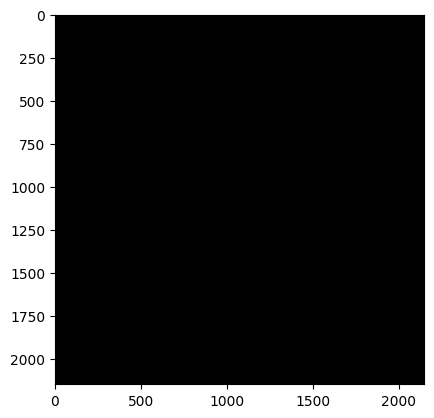

In [ ]:
from astropy.io import fits
# /content/drive/MyDrive/Colab Notebooks/hst_05773_05_wfpc2_f502n_wf_drz.fits
# /content/drive/MyDrive/Colab Notebooks/hst_05773_05_wfpc2_f656n_pc_drz.fits
# /content/drive/MyDrive/Colab Notebooks/hst_05773_05_wfpc2_f656n_wf_drz.fits
# /content/drive/MyDrive/Colab Notebooks/hst_05773_05_wfpc2_f673n_wf_drz.fits

hdulist=fits.open("/content/drive/MyDrive/Colab Notebooks/hst_05773_05_wfpc2_f673n_wf_drz.fits")
hdulist.info() # Open Hubble Space Telescope images with HDU contains meta-information.
hdulist[0].header
hdulist[0].header["EXPTIME"] # ["EXPTIME"] gives the exposure time in seconds.
hdulist[1].header # hdulist[1].header calls the science image SCI with index 1 (2nd HDU)
hdulist[1].header["NAXIS1"] # ["NAXIS1"] give the number of pixels.
hdulist[1].header["BUNIT"]
imdata =  hdulist[1].data # data gives the image data.
imdata
plt.clf()
plt.axes().set_aspect("equal") # set_aspect('equal') tells matplotlib that both x and y axes should have the same scale.
plt.imshow(imdata,cmap="gray") # imshow function display the image w/ cmap to use grayscale. The result is at first rather dark.
plt.show()

We now map the high contrast of the FITS image to our more modestly contrasted version, with use the clim option to map a more
restricted range of values to our image. Let look at the 1st and 99th percentile values of the image data (i.e. the brightness
value below which the darkest 1% of the pixels fall, and the brightness value above which 1% of the pixels fall).

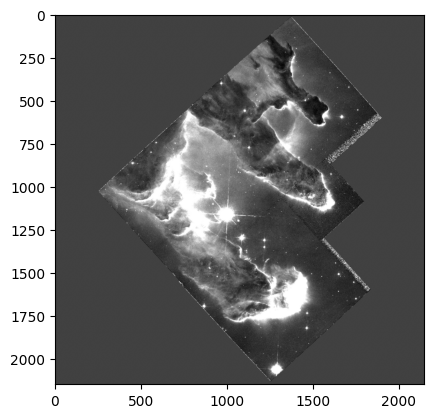

In [ ]:
import numpy as np
np.percentile(imdata,1)
np.percentile(imdata,99)
# clim option map a more restricted range of values to our image
plt.clf()
plt.axes().set_aspect("equal")
plt.imshow(imdata,cmap="gray",clim=(-0.03,0.088)) # -0.03 & 0.088 correspond to 1% and 99% persentile respectively
#plt.imshow(imdata,cmap="gray",clim=(-0.05,0.058))
plt.show()

PIXELWISE OPERATIONS - type of image data we have put on display is an array.
2150  2150.

In [ ]:
type(imdata) # type of image data we have put on display is an array.
imdata.shape # shape shows the image is a Numpy array
imdata[1400][1200] # retrieved the brightness value of the pixel at x = 1200, y = 1400.

np.float32(-0.0026838768)

Operations on the SDSS data image file frame-g-007923-5-0307.fits downloaded from https://dr9.sdss.org/fields/<br>
Search by Object Coordinates for RA 20.0 and Dec 20.0 and click on the link €-band FITS
# This web services have been deprecated as of August 2024

In [ ]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
hdulistS=fits.open("frame-g-007923-5-0307.fits")
imdataS=hdulistS[0].data
imdataS
lowerOne = np.percentile(imdataS,1)
lowerOne
upperOne = np.percentile(imdataS,99)
upperOne
plt.clf()
plt.imshow(imdataS,cmap="gray",clim=(lowerOne,upperOne))
plt.show()
#plt.savefig("sdss-py.pdf",bbox_inches="tight")

FileNotFoundError: [Errno 2] No such file or directory: 'frame-g-007923-5-0307.fits'

SIMULATION <br>
1) provide a point of comparison for observations <br>
2) e.g. IllustrisTNG27 simulation follow a cubic region within the cosmos from shortly after the Big Bang to the present.<br>
3) This example is the Euler method of the harmonic oscillator: A particle with mass $m$, which can move only in the (horizontal) $x$ direction, is fixed to the wall with a spring. If the particle is displaced from its rest position at $x = 0$, the spring exerts a force following Hooke's law, $Fₓ = -k⋅x$, with $k$ the spring constant. Its equation of motion, $m\ddot{x} = -k⋅x$, linking the $x$ acceleration $\ddot{x}$ and the force using Newton's second law, is readily solved analytically. The solution is <br>

>>> $x(t)= A⋅Sin(ωt)$,<br>

where the angular frequency $ω$ is linked to the system's oscillation period $T$ by the definition $ω = \frac{2π}{T}$, and the equations of motion demand $ω = \sqrt{\frac{k}{m}}$. Differentiating the solution equation once with respect to time, we have <br>

>>> $\dot{x} = ω⋅A⋅cos(ωt)$, <br>

and differentiating with respect to time once more, <br>

>>> $\ddot{x} = -ω^2⋅A⋅Sin(ωt) = -\frac{k}{m}⋅x$.<br>



To simulate the system, i.e. find a solution numerically, we look at very small time interval, all of the changes will be approximately linear, $dx=\dot{x}⋅dt$. Replace the infinitesimally small interval $dt$ by a finite small interval $\vartriangle t$. if we know the particle's $x$ position at one time $t$, we can estimate its position at a slightly later time $t +\vartriangle t$ as <br>

>>> $x(t+\vartriangle t)=x(t)+v(t)⋅\vartriangle t$. <br>

The rate of change of the velocity is the acceleration, which by Newton second law $F=m\ddot{x}$ is linked to the force acting on the particle. Thus, to obtain the velocity at some time $t+\vartriangle t$, with the approximation <br>

>>> $v(t+\vartriangle t)=v(t)+ \ddot{x}(t)⋅\vartriangle t = v(t)+ \frac{F(t)}{m}⋅\vartriangle t.$<br>

Now, discretize the whole problem: consider time steps $t_i$, with $i=1,...,N$, and evaluate the position and the velocity of our particle at each step. We choose the times $t_i$ equidistant, with $t_{i+1} - t_i = \vartriangle t $ for all $i$, for some fixed, small $\vartriangle t$ (much smaller than the system natural period $T$). Differential equations do not completely determine what is happening. It is necessary to specify initial conditions in order to define a unique solution.  Let us choose an initial position $x_0$ and initial speed $v_0$ for our particle.<br>


Let $x_i$ be the object position at time $t_i$, <br>

>>> $x_{i+1} = x_i + v_i⋅\vartriangle t$.<br>

$v_i$ is its velocity in $x$ direction at that time, $a_i$ its acceleration and $F_i$ the force acting on it at the time. In our case, with the Hooke force, the force depends only on the position, so the velocity equation reads, <br>

>>> $v_{i+1} = v_i + a_i ⋅\vartriangle t= v_i + \frac{F_i}{m} ⋅\vartriangle t = v_i - \frac{k}{m} x_i⋅\vartriangle t$.<br>


The process of following the evolution step by step is called $numerical$ $integration$, and the algorithm for going from one step to the next is called $Euler's$ $method$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
k=0.5
m=1.0
numberOfSteps = 30000
DeltaT = 0.001
finalT =numberOfSteps*DeltaT
# tCollector is only defined in preparation of plotting positions against time later on, and not used in the numerical integration itself.
tCollector=np.linspace(0,finalT,numberOfSteps+1)
# Initial conditions:
xCollector=[1.0]
vCollector=[0]
# Implemented the simulation of position x and velocity v, using the loop function.
for ii in range(numberOfSteps):
  xNew = xCollector[-1] + DeltaT*vCollector[-1]
  vNew = vCollector[-1] + DeltaT*(-k/m*xCollector[-1])
  xCollector.append(xNew)
  vCollector.append(vNew)
  #print(ii, "tCollector = ", tCollector[ii],"xCollector = ", xCollector[ii], "vCollector = ", vCollector[ii])

# print("The last xCollector", ii, xCollector)
# print("The last vCollector", ii, vCollector)

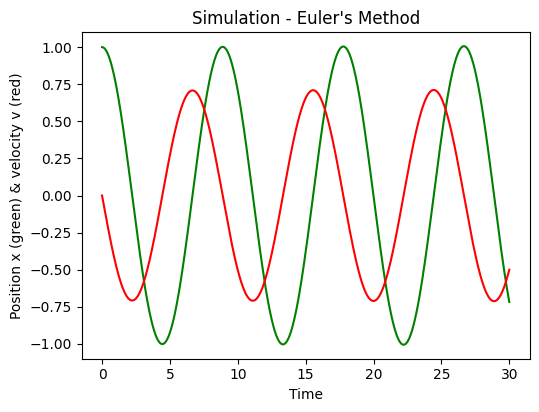

In [ ]:
plt.clf()
plt.subplots_adjust(bottom=.2, left=.2)
plt.title("Simulation - Euler's Method")
plt.xlabel("Time")
plt.ylabel("Position x (green) & velocity v (red)")
plt.ylim(-1.1,1.1)
plt.plot(tCollector,xCollector, color ='g', label='x')
plt.plot(tCollector,vCollector, color ='r', label='v')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
k=0.5
m=1.0
numberOfSteps = 30000
DeltaT = 0.001
tCollector=np.linspace(0,numberOfSteps*DeltaT,numberOfSteps+1)
# Initial conditions:
xCollector=[1.0]
yCollector=[1.0]
xydifference =[0.0]
vCollector=[0]
for ii in range(numberOfSteps):
    # numerical simulation
    xNew = xCollector[-1] + DeltaT*vCollector[-1]
    vNew = vCollector[-1] + DeltaT*(-k/m*xCollector[-1])
    # analytical calculation
    yNew =  np.sin(np.pi/2-np.sqrt(k/m)*tCollector[ii])
    # append to the array
    xCollector.append(xNew)
    vCollector.append(vNew)
    yCollector.append(yNew)
    # calculate the difference numerical vs analytical
    xydifference.append(xNew-yNew)

    #print("ii ={}".format(ii))
    #print("tCollector = {}".format(tCollector[ii]))
    #print("xCollector = {}".format(xCollector[ii]))
    #print("yCollector = {}".format(yCollector[ii]))
    #print("xydifference = {}".format(xydifference[ii]))

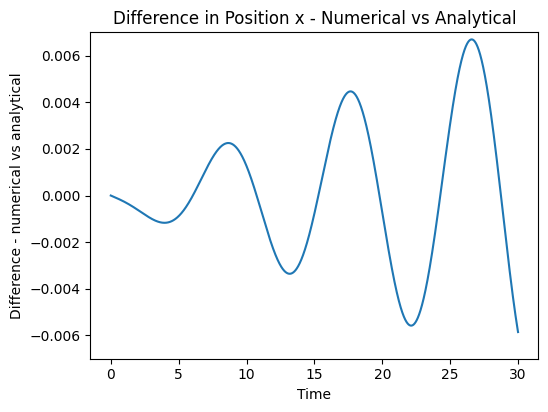

In [ ]:
# plot the difference xCollector(numerical) vs yCollector(analytical)
plt.clf()
plt.subplots_adjust(bottom=.2, left=.2)
plt.title("Difference in Position x - Numerical vs Analytical")
plt.xlabel("Time")

# the differences are getting larger over time, so the numerical simulation is unstable in this sense.
plt.ylabel("Difference - numerical vs analytical")
plt.ylim(-0.007,0.007)
plt.plot(tCollector,xydifference)
plt.show()


Let $x_i$ be the object position at time $t_i$, <br>

>>> $x_{i+1} = x_i + v_i⋅\vartriangle t$.<br>

$v_i$ is its velocity in $x$ direction at that time, $a_i$ its acceleration and $F_i$ the force acting on it at the time. In our case, with the Hooke force, the force depends only on the position, so the velocity equation reads, <br>

>>> $v_{i+1} = v_i + a_i ⋅\vartriangle t= v_i + \frac{F_i}{m} ⋅\vartriangle t = v_i - \frac{k}{m} x_i⋅\vartriangle t$.<br>

VERLET algorithm introduces “half-step” velocities, to mitigate the unstability problem, for a better-behaved numerical integration.<br>


>>> $v_{i+\frac{1}{2}} = v_i + \frac{1}{2} a_i ⋅\vartriangle t$<br>

>>> $x_{i+1} = x_i + v_{i+\frac{1}{2}}⋅\vartriangle t$<br>

>>> $v_{i+1} = v_{i+\frac{1}{2}} + \frac{1}{2}a_{i+1}⋅\vartriangle t$,<br>


where the $a_i$ is calculated from the force acting in time step $i$. In this algorithm, we avoid always using the initial values of rates-of-change at each time step, leading to systematic errors; instead, the calculation of $x_{i+1}$ uses the intermediate velocity, while the transition from $v_1$ to $v_{i+1}$ proceeds in two steps, one using the acceleration value at the beginning, the second the one at the end of the interval $\vartriangle t$.<br>

The velocity Verlet algorithm is unstable in the long-term too, with the error increasing over time. But the simple of expedient of adding the half-step velocity has greatly improved the accuracy.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
k=0.5
m=1.0
numberOfSteps = 30000

DeltaT = 0.001
finalT =numberOfSteps*DeltaT

# tCollector is only defined in preparation of plotting positions against time later on, and not used in the numerical integration itself.
tCollector=np.linspace(0,finalT,numberOfSteps+1)
# Initial conditions:
xCollectorVV=[1.0]
vCollectorVV=[0]

# Implemented the simulation of position x and velocity v, using the loop function.
for ii in range(numberOfSteps):
  vHalf = vCollectorVV[-1] + 0.5*DeltaT*(-k/m*xCollectorVV[-1])
  xNewVV = xCollectorVV[-1] + DeltaT*vHalf
  vNewVV = vHalf + 0.5*DeltaT*(-k/m*xNewVV)
  xCollectorVV.append(xNewVV)
  vCollectorVV.append(vNewVV)
  #print(ii, "tCollector = ", tCollector[ii],"xCollectorVV = ", xCollectorVV[ii], "vCollectorVV = ", vCollectorVV[ii])

#print("The last xCollectorVV", ii, xCollectorVV)
#print("The last vCollectorVV", ii, vCollectorVV)

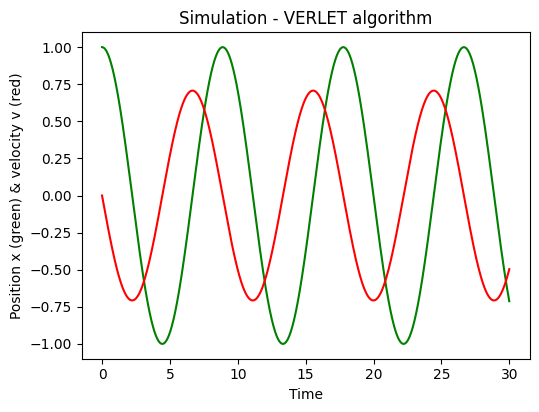

In [ ]:
plt.clf()
plt.subplots_adjust(bottom=.2, left=.2)
plt.title("Simulation - VERLET algorithm")
plt.xlabel("Time")
plt.ylabel("Position x (green) & velocity v (red)")
plt.ylim(-1.1,1.1)
plt.plot(tCollector,xCollectorVV, color ='g', label='x')
plt.plot(tCollector,vCollectorVV, color ='r', label='v')
plt.show()

In [ ]:
k=0.5
m=1.0
# numberOfSteps = 30000
numberOfSteps = 30000
DeltaT = 0.001
tCollector=np.linspace(0,numberOfSteps*DeltaT,numberOfSteps+1)
# Initial conditions:
xCollectorVV=[1.0]
yCollectorVV=[1.0]
xydifferenceVV =[0.0]
vCollectorVV=[0]
for ii in range(numberOfSteps):
    # numerical simulation
    xNewVV = xCollectorVV[-1] + DeltaT*vCollectorVV[-1]
    vNewVV = vCollectorVV[-1] + DeltaT*(-k/m*xCollectorVV[-1])
    # analytical calculation
    yNewVV =  np.sin(np.pi/2-np.sqrt(k/m)*tCollector[ii])
    # append to the array
    xCollectorVV.append(xNewVV)
    vCollectorVV.append(vNewVV)
    yCollectorVV.append(yNewVV)
    # calculate the difference numerical vs analytical
    xydifferenceVV.append(xNewVV-yNewVV)
    print("xydifference = {}".format(xydifferenceVV[ii]))


xydifference = 0.0
xydifference = 0.0
xydifference = -2.500000103600186e-07
xydifference = -5.000001666033427e-07
xydifference = -7.500005937410847e-07
xydifference = -1.0000014165623128e-06
xydifference = -1.250002760300184e-06
xydifference = -1.5000047498547886e-06
xydifference = -1.7500075103482615e-06
xydifference = -2.0000111665696707e-06
xydifference = -2.2500158435301287e-06
xydifference = -2.5000216664627928e-06
xydifference = -2.750028760156731e-06
xydifference = -3.0000372496230554e-06
xydifference = -3.250047259872879e-06
xydifference = -3.5000589159173146e-06
xydifference = -3.750072342656452e-06
xydifference = -4.000087665212426e-06
xydifference = -4.250105008374305e-06
xydifference = -4.500124497375246e-06
xydifference = -4.750146257004317e-06
xydifference = -5.000170412272631e-06
xydifference = -5.250197088080277e-06
xydifference = -5.500226409438369e-06
xydifference = -5.750258501469041e-06
xydifference = -6.000293488850339e-06
xydifference = -6.25033149681542e-06
xydif

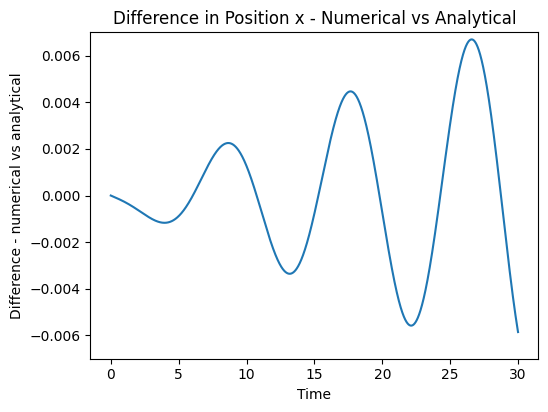

In [ ]:
# plot the difference xCollector(numerical) vs yCollector(analytical)
plt.clf()
plt.subplots_adjust(bottom=.2, left=.2)
plt.title("Difference in Position x - Numerical vs Analytical")
plt.xlabel("Time")

# the differences are getting larger over time, so the numerical simulation is unstable in this sense.
plt.ylabel("Difference - numerical vs analytical")
plt.ylim(-0.007,0.007)
plt.plot(tCollector,xydifferenceVV)
plt.show()

A 2-dimensional Simulation - Planet with mass m orbiting in the xy plane under the gravitaional influence of a central mass M in the origin (Newtonian gravity). <br>


The distance of the planet from the origin<br>

>>> $r = \sqrt{x^2 + y^2}$<br>

having applied the Pythagorean theorem,

>>> $\frac{F_x}{F}  = \frac{x}{r}$  and  $\frac{F_y}{F}  = \frac{y}{r}$.<br>

For the Newtonian gravitational force, we have

>>> $F  = - \frac{GMm}{r^2}$

Using $F_x  = ma_x$ and $F_y  = ma_y$ for the link between the force and the acceleration components, we have<br>

>>> $v_{x, i+\frac{1}{2}} = v_{x,i} + \frac{1}{2} a_{x,i}  ⋅\vartriangle t$<br>

>>> $x_{i+1} = x_i + v_{x,i+\frac{1}{2}}⋅\vartriangle t$<br>

>>> $v_{x,i+1} = v_{x,i+\frac{1}{2}} + \frac{1}{2}a_{x,i+1}⋅\vartriangle t$,<br>

and analogous equations linking the $v_y$ and $y$ values. Note that, via $r$, the force at any given step, and thus the acceleration components, depend on both coordinates.

Next, we need to choose suitable units. Let the central mass have one solar mass, $M_⊙ = 2·10^{30} kg$. Going by Earth’s orbit, a suitable unit of length is the astronomical unit (average Earth-Sun distance), $1 au = 1.5·10^{11} m$. As our unit of time, we choose the Julian year: 365.25 standard days, abbreviated as $a$ for the latin “annum” for year, related to the SI unit, the second, as $1 a = 31 557 600 s∼ π·10^7 s$. The corresponding unit for speed is<br>

>>> $v = 1 \frac{km}{s}  = 0.21\frac{au}{a}$

and the acceleration felt by the planet is given by (converted from  unit $\frac{m}{s^2}$)

>>> $a = \frac{F}{m}  = - \frac{GM}{r^2} = -39.48(\frac{1 au}{r})^2 \frac{au}{a^2}$


In [34]:
import numpy as np
import matplotlib.pyplot as plt
numberOfSteps = 30000
# numberOfSteps = 30000

DeltaT = 0.0001
accFac = 39.48 # Corresponding to one solar mass in au per square year
finalT=numberOfSteps*DeltaT
tCollector=np.linspace(0,finalT,numberOfSteps+1)
# Initial conditions:
xCollector=[1.5]
vxCollector=[0]
yCollector=[0.0]
vyCollector=[2.0]

In [35]:
for ii in range(numberOfSteps):
  rNow = np.sqrt(xCollector[-1]**2+yCollector[-1]**2)
  accNow = -accFac/rNow**2 #adjust the accelleration by distance from focus
  accNowx= accNow*xCollector[-1]/rNow # a_x
  accNowy= accNow*yCollector[-1]/rNow # a_y
  #print("ii ={}".format(ii))
  #print("xCollector = {}".format(xCollector))
  #print("yCollector = {}".format(yCollector))
  #print("rNow = {}".format(rNow))
  #print("accNow = {}".format(accNow))
  #print("accNowx = {}".format(accNowx))
  #print("accNowy = {}".format(accNowy))
  vxHalf = vxCollector[-1] + 0.5*DeltaT*accNowx
  vyHalf = vyCollector[-1] + 0.5*DeltaT*accNowy
  xNew = xCollector[-1] + DeltaT*vxHalf
  yNew = yCollector[-1] + DeltaT*vyHalf
  rNew = np.sqrt(xNew**2 + yNew**2)
  accNew = -accFac/rNew**2
  accNewx = accNew*xNew/rNew
  accNewy = accNew*yNew/rNew
  vxNew = vxHalf + 0.5*DeltaT*accNewx
  vyNew = vyHalf + 0.5*DeltaT*accNewy
  xCollector.append(xNew)
  yCollector.append(yNew)
  vxCollector.append(vxNew)
  vyCollector.append(vyNew)


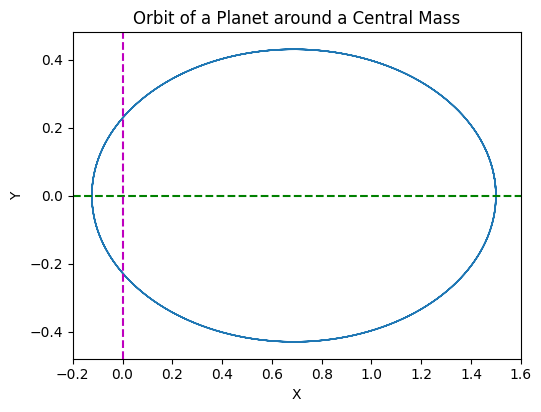

In [36]:
# plot the xCollector vs yCollector - If it is an elliptical orbit, confirm Kepler’s first law: the orbit of a planet orbiting a central mass is an ellipse, with the central mass in one of the focal points
plt.clf()
plt.subplots_adjust(bottom=.2, left=.2)
plt.title("Orbit of a Planet around a Central Mass")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(-0.20,1.60)
plt.ylim(-0.48,0.48)

plt.plot(xCollector,yCollector, lw=1.0)
plt.axhline(0.0,color="g",linestyle="dashed")  # one of the focus points at x = 0.0
plt.axvline(0.0,color="m",linestyle="dashed")  # one of the focus points at y = 0.0
plt.show()

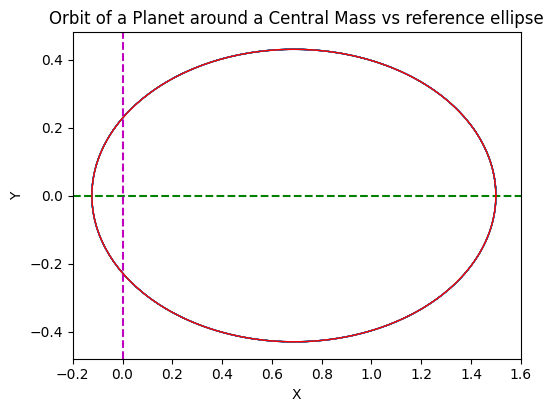

In [37]:

# plot the reference ellipse to compare with the simulated orbit.
majoraxis = np.max(xCollector) - np.min(xCollector) # major axis  a = 1.623 au.
minoraxis = np.max(yCollector) - np.min(yCollector) # minor axis  b = 0.860 au.
xc = np.min(xCollector) + (np.max(xCollector) - np.min(xCollector))/2  #x-position of the center
yc = np.min(yCollector) + (np.max(yCollector) - np.min(yCollector))/2  #y-position of the center
eccentricity =  np.sqrt(1 - minoraxis**2/majoraxis**2) # eccentricity e = 0.848.

plt.clf()
plt.subplots_adjust(bottom=.2, left=.2)
plt.title("Orbit of a Planet around a Central Mass vs reference ellipse")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(-0.20,1.60)
plt.ylim(-0.48,0.48)

plt.plot(xCollector,yCollector, lw=1.0)
plt.axhline(0.0,color="g",linestyle="dashed")  # one of the focus points at x = 0.0
plt.axvline(0.0,color="m",linestyle="dashed")  # one of the focus points at y = 0.0
theta = np.linspace(0, 2*np.pi, 100)
plt.plot( xc+majoraxis*np.cos(theta)/2 , yc+minoraxis*np.sin(theta)/2, "r",lw=1.0)
plt.show()

In [38]:
# np.min(xCollector) + np.max(xCollector)
# np.min(yCollector) + np.max(yCollector)
print("np.min(xCollector) = {}".format(np.min(xCollector)))
print("np.max(xCollector)  = {}".format(np.max(xCollector)))
print("np.min(yCollector) = {}".format(np.min(yCollector)))
print("np.max(yCollector)  = {}".format(np.max(yCollector)))

np.min(xCollector) = -0.12335823920305192
np.max(xCollector)  = 1.5
np.min(yCollector) = -0.43032456159454446
np.max(yCollector)  = 0.43015453188244557


Now we put our simulation to the test, let us see if we can recover Kepler's three laws of planetary motion from our simulation. Taking the minimum and maximum x value on our simulated orbit, we find that the left_most point of the orbit is at $x = -0.12335823920305192$, while the rightmost point is at $x = 1.5$. Thus the simulated orbit has a major half axis of $a = 1.623 au$. From the minimum $y = -0.43032456159454446$ and maximum $y = 0.43015453188244557$ coordinate value, the minor half axis  is $b = 0.860 au$<br>

For an ellipse, that would correspond to an eccentricity of<br>


>>> $e = \sqrt{1 - \frac{b^2}{a^2}} = 0.848$<br>

The polar coordinate equation for an ellipse is <br>

>>> $r(\theta)  = \frac{a(1-e^2)}{1+e⋅cos(\theta)}$<br>

Inserting our parameter values $a$ and $e$, we can plot this reference ellipse and compare with the simulated orbit. The resulting plot looks just like above, with one ellipse directly on top of the other. At least qualitatively, we have indeed confirmed :<br>

> Kepler’s first law: the orbit of a planet orbiting a central mass is an ellipse, with the central mass in one of the focal points. <br>

More quantitatively, we can compare analytical solution and simulation directly. There are several possibilities for this; with the following piece of code, each simulated point calculates the position angle $\theta $ and distance $r$ from the focus point, and compute the absolute value of the diﬀerence between the simulated value $r$ and the analytical value $r(\theta)$:<br>


In [39]:
diffCollector=[]
for x,y in zip(xCollector,yCollector):
    r=np.sqrt(x**2+y**2) # simulated value r for the ellipse
    theta = np.arctan2(y,x) # angle in radian
    anr = 0.5*(np.max(xCollector) - np.min(xCollector))*(1-eccentricity**2)/(1-eccentricity*np.cos(theta)) # analytical r(θ) for an ellipse
    # anr2 = 0.5*(np.max(xCollector) - np.min(xCollector))*(1-eccentricity**2)/(1+eccentricity*np.cos(theta)) # analytical r(θ) for an ellipse with +ve sign

    diffr = np.sqrt((r-anr)**2)
    diffCollector.append(diffr)
    # print(diffr)

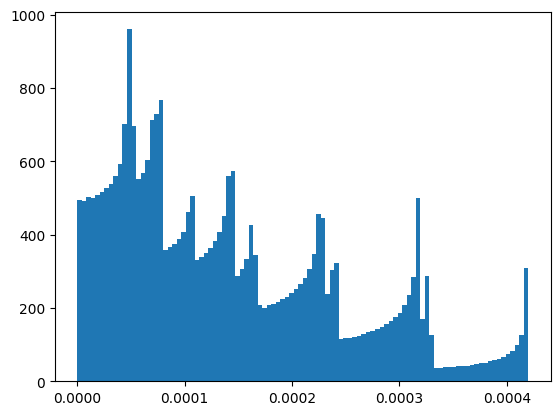

In [40]:
#The histogram of the values contained in diffCollector - shows the cascade-like  systematic errors involved in the simulation. The largest deviation is 4/10 000 of an au (half axis length of our orbit), i.e. deviation is fairly small, and simulated planet appears to have an elliptical orbit.
plt.clf()
plt.hist(diffCollector,bins=100)
plt.show()

start here

> Kepler’s second law: the connecting line between the planet and the central mass sweeps out equal areas in equal time intervals. <br>

Each of our time steps defines the same time interval, so if we calculate the triangle swept out in each time step (whose three vertices are the planet’s
position at the beginning and at the end of the time step, and the location of the central mass), we should always obtain the same area.
For each triangle,  x and y coordinates of all three vertices can calculate all the side lengths a,b,c using the Pythagorean theorem. Heron’s formula calculate the triangle’s area as A = √(s(s−a)(s−b)(s−c)), where s = (a+b+c)/2 is the triangle’s semi-perimeter
The following bit of code collects the relative deviation of each such triangle area from the mean in an array relativeDiff

In [ ]:
areaCollector=np.array([])
for x1, x2, y1, y2 in zip(xCollector[1:],xCollector[:-1],yCollector[1:],yCollector[:-1]):
  a = np.sqrt(x1**2+y1**2)
  b = np.sqrt(x2**2+y2**2)
  c = np.sqrt((x1-x2)**2+(y1-y2)**2)
  s = 0.5*(a+b+c)
  A = np.sqrt(s*(s-a)*(s-b)*(s-c))
  areaCollector = np.append(areaCollector,A)
averageArea=np.average(areaCollector)
relativeDiff = (areaCollector-averageArea)/averageArea

# The histogram of the values in relativeDiff shows that all those areas, swept out in the same time interval, are indeed very close to their average value
# The distribution shows a strong maximum at the average area value, with small (a few parts in a trillion!) fluctuations to smaller and larger values.
plt.clf()
plt.xlabel("Histogram of relative difference \nfrom averaged triangle areas for each time step")
plt.hist(relativeDiff,bins=47)
plt.show()

Kepler’s third law -  the orbital periods T is proportional to major elliptical half axis a as a**3/T**2. The advanced form of Kepler’s law found by Newton is a**3/T**2 = GM/4π**2
The plot of y coordinate of our planet against time is unsurprisingly periodical.

In [ ]:
plt.clf()
plt.subplots_adjust(bottom=.2, left=.2)
plt.xlabel("Time in years")
plt.xlim(xCollector)
plt.ylabel("y coordinate in au")
plt.ylim(-0.48,0.48)
plt.plot(tCollector,yCollector, lw=1.0)
plt.show()

We have already estimated a. Let us do the same for period T. We fold the time evolution by assuming a value for the period T,
and define the phase as φ = np.mod(tCollector/T, 1), i.e. all integer multiples of the period T get mapped to 0, and all times
written as t = (n + φ) · T with integer n and 0 ≤ φ < 1 get mapped to φ. After a few dozen tries, the final round with a
microscopic look at the steepest curve region via plt.xlim(0.475,0.525), arrive at T = 0.7313a(year). We could automate this
sorting the phase values into different arrays indexed by the integer part of t/T, and minimising the differences between those
partial curves. This is very similar to how you determine the orbital of an exoplanet by folding the light curve data (from the
transit method) or Doppler shift data (in the radial velocity method).

In [ ]:
T = np.array([0.7313 for ii in range(30001)]) #fill the array T with estimated value
φ = np.mod(tCollector/T, 1)
#len(φ)
#np.info(φ)
#np.info(phase)
#φ[27091:27991]
plt.clf()
plt.subplots_adjust(bottom=.2, left=.2)
plt.xlabel("Phase")
plt.xlim(-0.05,1.05)
#plt.xlim(0.475,0.525)
plt.ylabel("y coordinate in au")
plt.ylim(-0.48,0.48)
plt.plot(φ,yCollector, lw=1.0)
plt.show()

Our final test is to see if this T value indeed satisfies equation a**3/T**2 = GM/4π**2, with right-hand side = 1 au**3/a**2,
since the Earth does have a semimajor axis of length 1 au and an orbital period of 1 year. Our simulation satisfies
(a/1au)**3 · (1a/T)**2= 0.99991.The two values coincide up to one part in 10 000. So our simulation reproduces Kepler’s third law.

In [ ]:
((majoraxis/2)**3)/((0.7313)**2)